In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [13]:
nav = pd.read_csv("../data/raw/nav_history.csv")

In [14]:
nav.head()

,Date,Scheme,NAV
0,2022-01-01,Scheme_01,50.17
1,2022-01-02,Scheme_01,50.15
2,2022-01-03,Scheme_01,50.36
3,2022-01-04,Scheme_01,50.84
4,2022-01-05,Scheme_01,50.79


In [5]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58440 entries, 0 to 58439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    58440 non-null  object 
 1   Scheme  58440 non-null  object 
 2   NAV     58440 non-null  float64
dtypes: float64(1), object(2)
memory usage: 1.3+ MB


In [6]:
nav.isnull().sum()

Date      0
Scheme    0
NAV       0
dtype: int64

In [7]:
nav["Date"] = pd.to_datetime(nav["Date"])

In [8]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58440 entries, 0 to 58439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    58440 non-null  datetime64[ns]
 1   Scheme  58440 non-null  object        
 2   NAV     58440 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 1.3+ MB


In [9]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58440 entries, 0 to 58439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    58440 non-null  datetime64[ns]
 1   Scheme  58440 non-null  object        
 2   NAV     58440 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 1.3+ MB


In [10]:
nav.isnull().sum()

Date      0
Scheme    0
NAV       0
dtype: int64

In [11]:
nav["Date"] = pd.to_datetime(nav["Date"])

In [12]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58440 entries, 0 to 58439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    58440 non-null  datetime64[ns]
 1   Scheme  58440 non-null  object        
 2   NAV     58440 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 1.3+ MB


In [16]:
fig = px.line(
    nav,
    x="Date",
    y="NAV",
    color="Scheme",
    title="Daily NAV Trend (2022–2025)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.2,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    fillcolor="red",
    opacity=0.2,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.show()
fig.write_image("../reports/nav_trend.png")

# Task 1: NAV Trend Analysis

## Objective
Plot the daily NAV trend for all 40 mutual fund schemes from 2022–2025 using Plotly. Highlight the 2023 Bull Run and 2024 Market Correction.

# Task 2: AUM Growth Analysis

## Objective
Create a grouped bar chart showing AUM growth of different fund houses from 2022 to 2025 using Seaborn. Highlight SBI's dominance with ₹12.5 Lakh Crore AUM.

In [30]:
aum = pd.read_csv("../data/raw/aum.csv")

In [31]:
aum.head()

,Year,Fund House,AUM_LakhCr
0,2022,SBI,8.50
1,2023,SBI,10.20
2,2024,SBI,11.30
3,2025,SBI,12.50
4,2022,HDFC,6.63


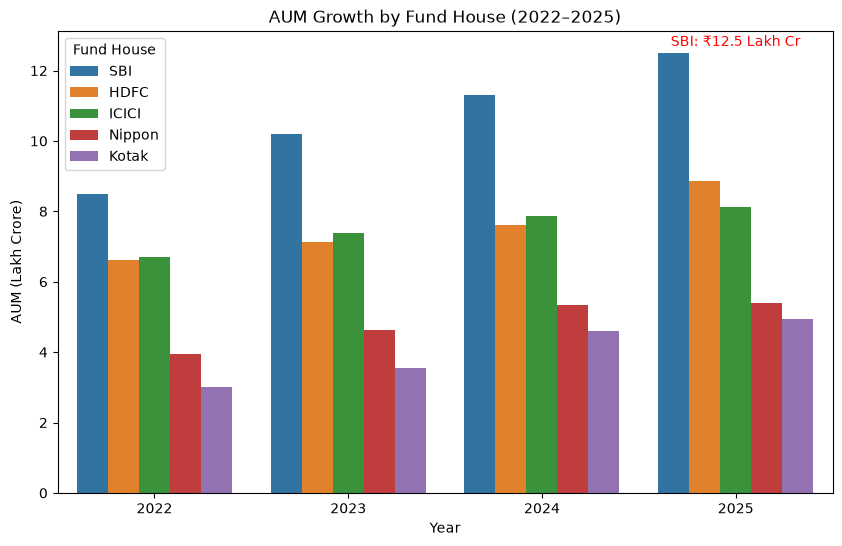

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    data = aum,
    x="Year",
    y="AUM_LakhCr",
    hue="Fund House"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.text(
    3,
    12.7,
    "SBI: ₹12.5 Lakh Cr",
    ha="center",
    fontsize=10,
    color="red"
)
plt.show()
fig.write_image("../reports/aum_growth.png")

### Insight
SBI Mutual Fund recorded the highest AUM among all fund houses, reaching ₹12.5 Lakh Crore in 2025, indicating its market leadership.

# Task 3: SIP Inflow Time-Series

## Objective
Visualize monthly SIP inflows from January 2022 to December 2025 using Plotly and highlight the all-time high of ₹31,002 Crore in December 2025.

In [26]:
sip = pd.read_csv("../data/raw/sip_inflows.csv")

In [27]:
sip.head()

,Month,SIP_Cr
0,2022-01,12000
1,2022-02,12404
2,2022-03,12809
3,2022-04,13213
4,2022-05,13617


In [28]:
sip["Month"] = pd.to_datetime(sip["Month"])

In [29]:
fig = px.line(
    sip,
    x="Month",
    y="SIP_Cr",
    title="Monthly SIP Inflows (2022–2025)",
    markers=True
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="₹31,002 Cr (All-Time High)",
    showarrow=True,
    arrowhead=2
)

fig.show()
fig.write_image("../reports/sip_trend.png")

### Insight
Monthly SIP inflows increased steadily from 2022 to 2025, reaching an all-time high of ₹31,002 Crore in December 2025, reflecting growing investor confidence.

# Task 4: Category Inflow Heatmap

## Objective
Visualize monthly net inflows across different mutual fund categories using a Seaborn heatmap.

In [33]:
category = pd.read_csv("../data/raw/category_inflow.csv")

In [34]:
category.head()

,Month,Category,Net_Inflow
0,Jan-2022,Large Cap,1846
1,Jan-2022,Mid Cap,470
2,Jan-2022,Small Cap,-156
3,Jan-2022,Hybrid,344
4,Jan-2022,Debt,921


In [35]:
heatmap_data = category.pivot(
    index="Category",
    columns="Month",
    values="Net_Inflow"
)

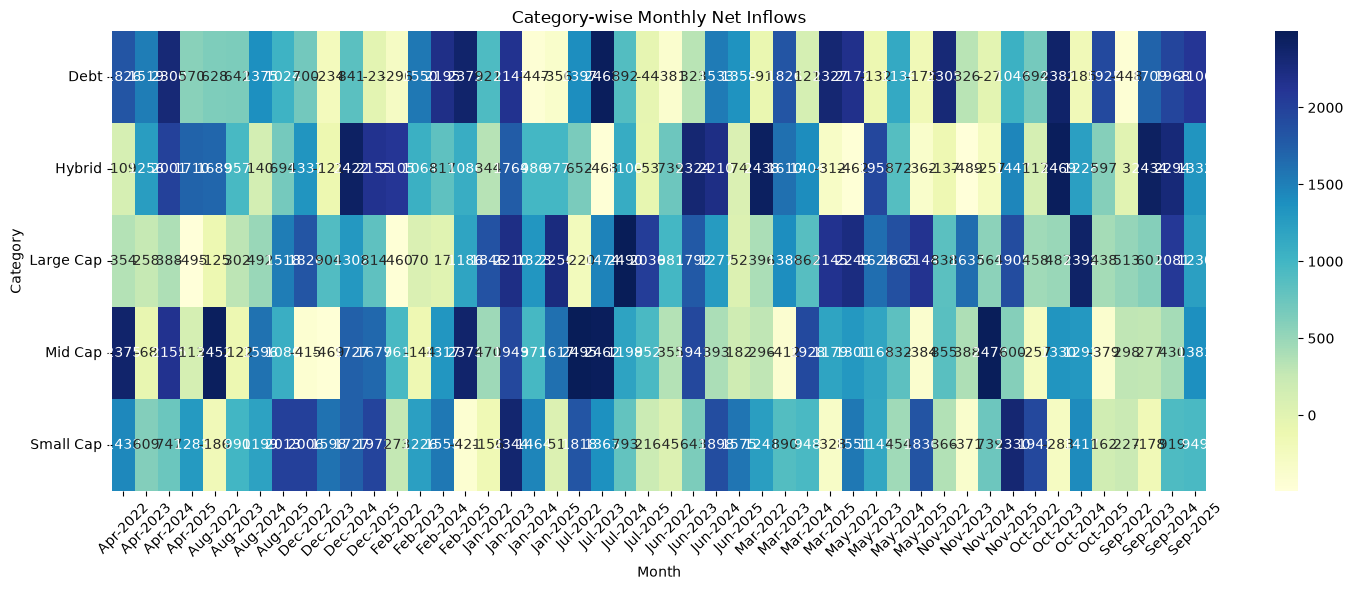

In [36]:
plt.figure(figsize=(15,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Monthly Net Inflows")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()
fig.write_image("../reports/category_heatmap.png")

### Insight

Equity funds received the highest net inflows across most months, while Debt and Hybrid funds showed comparatively moderate inflows.

In [37]:
investors = pd.read_csv("../data/raw/investors.csv")
investors.head()

,Age_Group,Gender,SIP_Amount,State,City_Tier
0,26-35,Male,8291,Tamil Nadu,T30
1,50+,Female,2789,Delhi,B30
2,18-25,Female,2992,Delhi,T30
3,26-35,Female,6180,Delhi,B30
4,50+,Male,2596,Maharashtra,T30


# 📊 Task 5: Investor Demographics Analysis

## 🎯 Objective
Analyze SIP investment amounts across different age groups and genders.

In [39]:
import plotly.express as px

fig = px.box(
    investors,
    x="Age_Group",
    y="SIP_Amount",
    color="Gender",
    title="SIP Amount Distribution by Age Group and Gender"
)

fig.show()
fig.write_image("../reports/investor_demographics.png")

## 💡 Insight

The 26–35 age group showed the highest SIP investment amounts overall. Male and female investors displayed similar investment patterns, with a few high-value outliers across different age groups.

# 🌍 Task 6: State-wise SIP Investment Analysis

## 🎯 Objective
Analyze the total SIP investment amount across different states.

In [58]:
import plotly.express as px

state_sip = investors.groupby("State", as_index=False)["SIP_Amount"].sum()

fig = px.bar(
    state_sip,
    x="State",
    y="SIP_Amount",
    color="State",
    title="Total SIP Investment by State",
    text_auto=True
)

fig.show()
fig.write_image("../reports/geographic_distribution.png")


## 💡 Insight

Among the available states, Maharashtra and Delhi contribute the highest total SIP investment, indicating stronger investor participation compared to the other states.

# 🏙️ Task 7: City Tier-wise SIP Investment Analysis

## 🎯 Objective
Compare total SIP investment across different city tiers.

In [ ]:
city_tier = investors.groupby("City_Tier", as_index=False)["SIP_Amount"].sum()

fig = px.pie(
    city_tier,
    names="City_Tier",
    values="SIP_Amount",
    title="SIP Investment by City Tier"
)

fig.show()

## 💡 Insight

The city tier with the larger share contributes a greater portion of the total SIP investment, highlighting stronger investment participation from that segment.

In [41]:
import pandas as pd

portfolio = pd.read_csv("../data/raw/portfolio_holdings.csv")
portfolio.head()

,Scheme,Sector,Weight
0,Scheme_01,IT,17.21
1,Scheme_01,Banking,6.70
2,Scheme_01,Pharma,9.23
3,Scheme_01,Auto,3.24
4,Scheme_01,FMCG,15.16


In [42]:
portfolio.columns

Index(['Scheme', 'Sector', 'Weight'], dtype='object')

In [57]:
import plotly.express as px

sector_weight = portfolio.groupby("Sector")["Weight"].sum().reset_index()

fig = px.pie(
    sector_weight,
    names="Sector",
    values="Weight",
    title="Portfolio Allocation by Sector",
    hole=0.4
)

fig.show()
fig.write_image("../reports/sector_allocation.png")

## 💡 Insight

The portfolio is diversified across multiple sectors. Sectors with higher portfolio weights represent the fund's major investment focus, while sectors with lower weights contribute to diversification and risk management.

In [44]:
import pandas as pd

folio = pd.read_csv("../data/raw/folio_count.csv")
folio.head()

,Month,Folio_Cr
0,2022-01,13.26
1,2022-02,13.53
2,2022-03,13.81
3,2022-04,14.08
4,2022-05,14.35


In [45]:
folio.columns

Index(['Month', 'Folio_Cr'], dtype='object')

In [46]:
import plotly.express as px

fig = px.line(
    folio,
    x="Month",
    y="Folio_Cr",
    title="Monthly Folio Count Trend",
    markers=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Folio Count (Cr)"
)

fig.show()
fig.write_image("../reports/folio_growth.png")

## 💡 Insight

The mutual fund folio count shows a steady upward trend over time, indicating consistent growth in investor participation. The increasing number of folios reflects rising awareness and confidence in mutual fund investments.

In [48]:
nav = pd.read_csv("../data/raw/HDFC_Top100_NAV.csv")

In [49]:
nav.head()

,date,nav
0,19-06-2026,202.0761
1,18-06-2026,200.9565
2,17-06-2026,199.8302
3,16-06-2026,198.6152
4,15-06-2026,198.0320


In [51]:
nav.columns 

Index(['date', 'nav'], dtype='object')

In [52]:
nav.columns

Index(['date', 'nav'], dtype='object')

In [53]:
nav.head()

,date,nav
0,19-06-2026,202.0761
1,18-06-2026,200.9565
2,17-06-2026,199.8302
3,16-06-2026,198.6152
4,15-06-2026,198.0320


In [54]:
nav_history = pd.read_csv("../data/raw/nav_history.csv")
nav_history.head() 

,Date,Scheme,NAV
0,2022-01-01,Scheme_01,50.17
1,2022-01-02,Scheme_01,50.15
2,2022-01-03,Scheme_01,50.36
3,2022-01-04,Scheme_01,50.84
4,2022-01-05,Scheme_01,50.79


In [55]:
nav_history.columns 

Index(['Date', 'Scheme', 'NAV'], dtype='object')

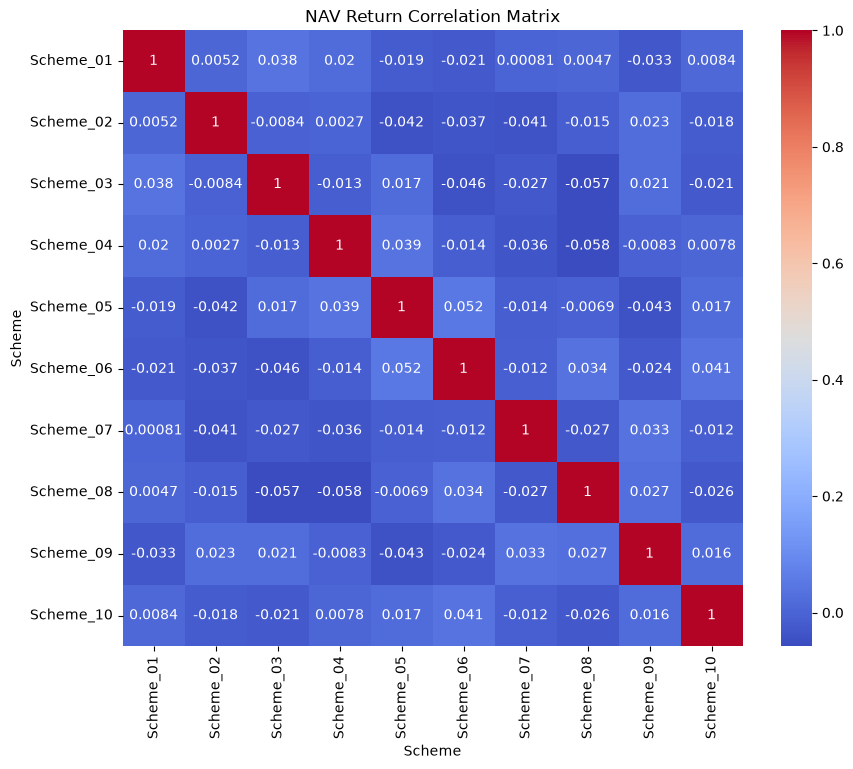

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select first 10 schemes
selected_schemes = nav_history["Scheme"].unique()[:10]

# Filter data
nav10 = nav_history[nav_history["Scheme"].isin(selected_schemes)]

# Convert into wide format
pivot_nav = nav10.pivot(index="Date", columns="Scheme", values="NAV")

# Calculate daily returns
returns = pivot_nav.pct_change().dropna()

# Correlation matrix
corr = returns.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("NAV Return Correlation Matrix")
plt.show()
fig.write_image("../reports/correlation_matrix.png")

## 💡 Insight
Most schemes show a positive correlation in daily NAV returns, indicating they generally move together with overall market trends. However, some schemes exhibit weaker correlations, suggesting diversification opportunities.

In [59]:
import plotly.express as px

fig = px.histogram(
    investors,
    x="SIP_Amount",
    nbins=20,
    title="Distribution of SIP Amount"
)

fig.show()
fig.write_image("../reports/sip_distribution.png")

## Insight
Most investors contribute a moderate SIP amount, while high SIP investments are comparatively fewer

In [60]:
state_count = investors["State"].value_counts().reset_index()
state_count.columns = ["State", "Count"]

fig = px.bar(
    state_count,
    x="State",
    y="Count",
    title="Number of Investors by State"
)

fig.show()
fig.write_image("../reports/investors_by_state.png")

## Insight
Some States have a larger investor base than others

In [61]:
gender = investors["Gender"].value_counts().reset_index()
gender.columns = ["Gender", "Count"]

fig = px.pie(
    gender,
    names="Gender",
    values="Count",
    title="Gender Distribution of Investors"
)

fig.show()
fig.write_image("../reports/gender_distribution.png")

## Insight
The investor base consists of both male and female investors with a noticeable participation difference.

In [62]:
avg = investors.groupby("Age_Group")["SIP_Amount"].mean().reset_index()

fig = px.bar(
    avg,
    x="Age_Group",
    y="SIP_Amount",
    title="Average SIP Amount by Age Group"
)

fig.show()
fig.write_image("../reports/avg_sip_age.png")

## Insight
Average SIP investment varies across different age groups

In [63]:
fig = px.histogram(
    nav_history,
    x="NAV",
    nbins=30,
    title="Distribution of NAV Values"
)

fig.show()
fig.write_image("../reports/nav_distribution.png")

## Insight
Most NAV values are concentrated within a specific range


In [64]:
top = nav_history.groupby("Scheme")["NAV"].mean().sort_values(ascending=False).head(10).reset_index()

fig = px.bar(
    top,
    x="Scheme",
    y="NAV",
    title="Top 10 Schemes by Average NAV"
)

fig.show()
fig.write_image("../reports/top10_nav.png")

## Insight
The top-performing schemes have consistently higher average NAV values